#### predictive modeling of soil oragnic carbon with samples from Italy ####

In [1]:
#install.packages("prospectr")
#install.packages("resemble")
#install.packages("caret")
#install.packages("pls")
#install.packages("randomForest")
#install.packages("ranger")

In [2]:
# loading necessary packages

library(prospectr)
library(resemble)
library(caret)
library(pls)
library(randomForest)
library(ranger)

prospectr version 0.2.8 -- galo

check the package repository at: https://github.com/l-ramirez-lopez/prospectr

resemble version 2.2.5 -- dstatements

check the package repository at: http://l-ramirez-lopez.github.io/resemble/

Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘pls’


The following object is masked from ‘package:caret’:

    R2


The following object is masked from ‘package:prospectr’:

    msc


The following object is masked from ‘package:stats’:

    loadings


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin



Attaching package: ‘ranger’


The following object is masked from ‘package:randomForest’:

    importance




In [3]:
# read the data and get the variables

setwd("/home/camahubuntu/Spectroscopy/italy_soc")

lab_raw <- read.csv("Italy_lab.csv")


VNIR_raw<-read.csv("Italy_spc.csv")
VNIR_raw<-VNIR_raw[,-1]

wl <- read.csv("Italy_spc.csv", header = FALSE)
wl <- as.numeric(wl[1, ])
wl <- wl[!is.na(wl)]

In [4]:
lab_raw

X,SAMPLE_ID,CLAY,SILT,SAND,SOC,CaCO3,N,P,K,CEC,GPS_PROJ,GPS_LAT,GPS_LONG,LC1,LC2,LU1,LU2,MINERAL,COUNTRY
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,13152,15,51,35,35.1,346,2.0,14.6,75.2,16.5,WGS84,45.97550,12.66835,B52,8,U111,8,mineral,ITALY
2,13153,8,57,35,62.6,418,1.4,27.1,58.0,8.3,WGS84,45.99018,12.79803,C10,8,U120,8,mineral,ITALY
3,13154,36,61,3,15.1,501,1.0,0.0,129.3,20.3,WGS84,45.88863,12.53528,B11,8,U111,8,mineral,ITALY
4,13155,25,65,10,25.8,498,1.5,0.0,72.7,16.9,WGS84,45.87001,12.56019,B51,8,U111,8,mineral,ITALY
5,13156,10,61,29,37.3,496,2.0,0.0,49.2,11.0,WGS84,45.95168,12.89902,C10,8,U120,8,mineral,ITALY
6,13158,39,58,3,29.6,402,2.5,48.9,121.4,23.3,WGS84,45.84271,12.91913,B16,8,U111,8,mineral,ITALY
7,13159,30,65,5,16.9,506,1.2,22.8,127.4,11.6,WGS84,45.73037,13.06721,B16,8,U111,8,mineral,ITALY
8,13160,19,46,35,26.3,2,2.2,28.0,315.1,14.9,WGS84,46.00109,13.05670,B13,8,U111,8,mineral,ITALY
9,13161,21,45,34,23.2,67,2.1,62.2,162.4,17.4,WGS84,46.00259,13.00516,B16,8,U111,8,mineral,ITALY


In [5]:
# now we remove all the outlayers
# Merge lab and VNIR first 
dat_all <- cbind(lab_raw, VNIR_raw)

# Remove rows where MINERAL == "organic"
dat_all <- dat_all[dat_all$MINERAL != "organic", ]

# Split back into lab and VNIR
lab  <- dat_all[, 1:ncol(lab_raw)]
VNIR <- dat_all[, (ncol(lab) + 1):ncol(dat_all)]

In [6]:
VNIR
lab

,X500,X502,X504,X506,X508,X510,X512,X514,X516,X518,⋯,X2480,X2482,X2484,X2486,X2488,X2490,X2492,X2494,X2496,X2498
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.13401595,0.13518842,0.13639392,0.13763535,0.13890856,0.14021436,0.14153977,0.14288890,0.14426501,0.14566728,⋯,0.4097656,0.4087210,0.4076482,0.4065524,0.4054114,0.4042383,0.4030742,0.4019541,0.4009276,0.4000060
2,0.19403385,0.19547085,0.19693754,0.19844767,0.19997951,0.20154754,0.20313652,0.20475735,0.20640632,0.20807433,⋯,0.4826669,0.4812292,0.4796368,0.4778736,0.4759716,0.4739854,0.4719810,0.4700310,0.4682001,0.4665256
3,0.35591066,0.35927583,0.36272751,0.36626802,0.36984777,0.37345820,0.37710084,0.38076542,0.38444879,0.38814009,⋯,0.5645716,0.5633580,0.5621659,0.5609879,0.5598188,0.5586728,0.5575875,0.5565478,0.5555863,0.5547752
4,0.27002781,0.27266067,0.27535661,0.27812114,0.28091763,0.28374486,0.28660087,0.28947696,0.29237955,0.29530582,⋯,0.5136154,0.5123102,0.5110278,0.5097298,0.5083941,0.5070438,0.5057431,0.5045207,0.5033841,0.5023605
5,0.17510014,0.17631428,0.17755770,0.17884014,0.18013993,0.18146087,0.18279655,0.18415542,0.18553058,0.18691816,⋯,0.4498855,0.4489009,0.4478303,0.4467067,0.4455577,0.4444225,0.4433396,0.4423372,0.4414469,0.4406797
6,0.21898860,0.22072829,0.22250512,0.22432827,0.22617729,0.22806414,0.22996778,0.23188759,0.23382045,0.23576265,⋯,0.5169279,0.5162178,0.5155034,0.5147508,0.5139762,0.5132400,0.5125450,0.5118686,0.5112437,0.5107266
7,0.27373826,0.27580745,0.27792909,0.28011089,0.28231536,0.28455125,0.28680816,0.28908097,0.29137414,0.29368719,⋯,0.5443096,0.5436514,0.5429458,0.5421931,0.5414352,0.5406678,0.5399344,0.5392945,0.5387403,0.5382320
8,0.09974072,0.10072876,0.10175693,0.10282175,0.10391829,0.10504454,0.10619572,0.10737421,0.10858167,0.10981812,⋯,0.3621554,0.3615301,0.3609313,0.3604010,0.3599204,0.3594699,0.3590558,0.3586877,0.3583856,0.3581360
9,0.09513822,0.09612016,0.09713763,0.09819254,0.09927914,0.10039290,0.10153307,0.10270285,0.10390382,0.10513638,⋯,0.3533190,0.3526590,0.3519666,0.3512877,0.3506497,0.3500499,0.3495003,0.3489932,0.3485247,0.3481509


,X,SAMPLE_ID,CLAY,SILT,SAND,SOC,CaCO3,N,P,K,CEC,GPS_PROJ,GPS_LAT,GPS_LONG,LC1,LC2,LU1,LU2,MINERAL,COUNTRY
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,13152,15,51,35,35.1,346,2.0,14.6,75.2,16.5,WGS84,45.97550,12.66835,B52,8,U111,8,mineral,ITALY
2,2,13153,8,57,35,62.6,418,1.4,27.1,58.0,8.3,WGS84,45.99018,12.79803,C10,8,U120,8,mineral,ITALY
3,3,13154,36,61,3,15.1,501,1.0,0.0,129.3,20.3,WGS84,45.88863,12.53528,B11,8,U111,8,mineral,ITALY
4,4,13155,25,65,10,25.8,498,1.5,0.0,72.7,16.9,WGS84,45.87001,12.56019,B51,8,U111,8,mineral,ITALY
5,5,13156,10,61,29,37.3,496,2.0,0.0,49.2,11.0,WGS84,45.95168,12.89902,C10,8,U120,8,mineral,ITALY
6,6,13158,39,58,3,29.6,402,2.5,48.9,121.4,23.3,WGS84,45.84271,12.91913,B16,8,U111,8,mineral,ITALY
7,7,13159,30,65,5,16.9,506,1.2,22.8,127.4,11.6,WGS84,45.73037,13.06721,B16,8,U111,8,mineral,ITALY
8,8,13160,19,46,35,26.3,2,2.2,28.0,315.1,14.9,WGS84,46.00109,13.05670,B13,8,U111,8,mineral,ITALY
9,9,13161,21,45,34,23.2,67,2.1,62.2,162.4,17.4,WGS84,46.00259,13.00516,B16,8,U111,8,mineral,ITALY


In [7]:
# define different preprocessing steps

nXr00<-as.matrix(VNIR) # reflectance without further preprocessing
nXr01<-sweep(nXr00, MARGIN=1, apply(nXr00, 1, function(x) (mean(x))), FUN="/")# mean centering # wirklich richtige Formel?
nXr02<-standardNormalVariate(nXr00) # SNV
nXr03<-detrend(nXr00, wl) # Detrend, requires additional information on wavelengths/wavenumbers
nXr04<-savitzkyGolay(nXr00, m=1, p=2, w=5) # 1st derivative (Savitzky-Golay)

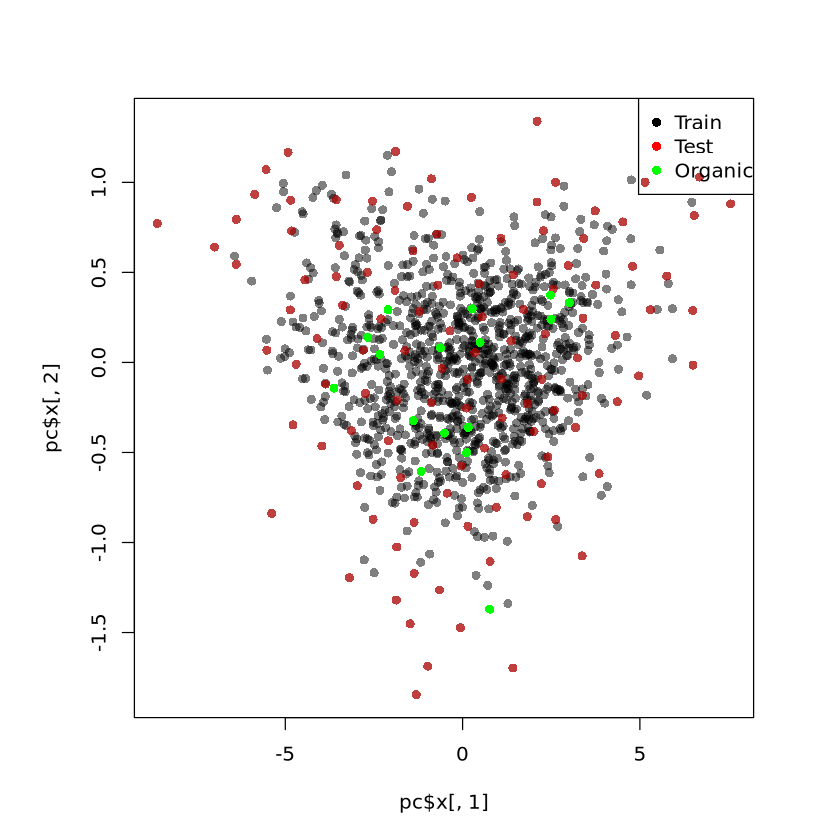

In [8]:
# Define organic samples
organic <- which(lab_raw$MINERAL == "organic")

# split the data (no preprocessing considered yet)
nXdat<-nXr00

# first we choose 10% of the data as validation
nt <- round(0.10 * nrow(nXdat))

# then we use a PC Kennard-Stone algorithm, to choose the validation points with a high variance 
split<-kenStone(X = nXdat, 
                k = nt, 
                metric="mahal",
                pc=0.95,   # based on PC feature space explaining 95% of overall variance of the spectra
                .center = TRUE,
                .scale = FALSE)


# which samples are defined as test set
test<-split$model

# which samples are defined as calibration set
train<-split$test # the naming is a bit confusing but is part of the function -> test is the rest of the data which was not considered in the kennard algorithm

# Plot in PC feature space
pc<-prcomp(nXdat, center=T, scale. = F, rank. = 5)

par(pty="s")      # pty="s" ---> squared plot, regardless of the plot window size
matplot(pc$x[,1],   # scores of first PC
        pc$x[,2],   # scores of second PC
        pch=16,
        col=adjustcolor("black", alpha.f=0.5))     # filled points

# adding test set
matpoints(pc$x[test,1], # only test set samples, 1st PC
          pc$x[test,2], # only test set samples, 2nd PC
          pch=16, 
          col=adjustcolor("red", alpha.f=0.5))

# Plot organic samples in blue (overlap on top)
matpoints(pc$x[organic,1], pc$x[organic,2], pch=16, col="green")

# Legend
legend("topright", legend=c("Train","Test","Organic"), 
       col=c("black","red","green"), pch=16)

In [9]:
organic

[1]   20   23   31  216  219  229  290  324  350  402  611  763  764  769 1121
[16] 1148

In [10]:
# how many PCs are considered in our case? does the plot show the whole feature space?

pca <- prcomp(nXdat, center = TRUE, scale. = FALSE)
var_explained <- pca$sdev^2 / sum(pca$sdev^2)
cumvar <- cumsum(var_explained)
n_pc_95 <- which(cumvar >= 0.95)[1]

n_pc_95


[1] 2

we get 2, which is ideal in our case, so the plot shows the whole feature space with 95% variance explained

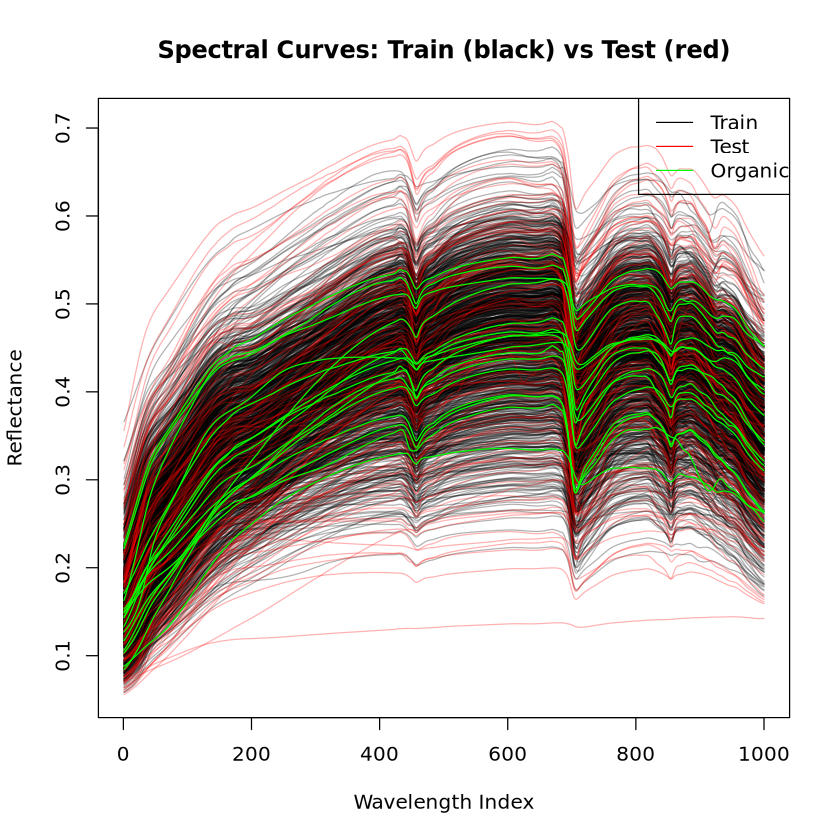

In [11]:
# Set up plot limits
ymin <- min(nXdat)
ymax <- max(nXdat)

# Plot all training spectra
matplot(t(nXdat[train, ]), type="l", lty=1, col=rgb(0,0,0,0.3),
        xlab="Wavelength Index", ylab="Reflectance", ylim=c(ymin, ymax),
        main="Spectral Curves: Train (black) vs Test (red)")

# Add test spectra
matlines(t(nXdat[test, ]), type="l", lty=1, col=rgb(1,0,0,0.3))

# Organic spectra (green)
matlines(t(nXdat[organic, ]), type="l", lty=1, col="green")

# Legend
legend("topright", legend=c("Train","Test","Organic"), 
       col=c("black","red","green"), lty=1)

# Add legend
#legend("topright", legend=c("Train","Test"), col=c("black","red"), lty=1)


Data: 	X dimension: 1048 1000 
	Y dimension: 1048 1
Fit method: oscorespls
Number of components considered: 20
TRAINING: % variance explained
        1 comps  2 comps  3 comps  4 comps  5 comps  6 comps  7 comps  8 comps
X        93.352    96.68    98.08    99.46    99.76    99.86    99.92    99.94
Ytrain    7.545    17.75    24.02    28.07    37.63    44.16    49.02    54.98
        9 comps  10 comps  11 comps  12 comps  13 comps  14 comps  15 comps
X         99.96     99.97     99.97     99.98     99.98     99.99     99.99
Ytrain    57.22     61.43     64.38     65.41     65.72     66.26     66.67
        16 comps  17 comps  18 comps  19 comps  20 comps
X          99.99     99.99     99.99     99.99     99.99
Ytrain     66.94     67.56     67.88     68.31     68.61
Data: 	X dimension: 1048 1000 
	Y dimension: 1048 1
Fit method: oscorespls
Number of components considered: 20

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 c

13 comps 
      13

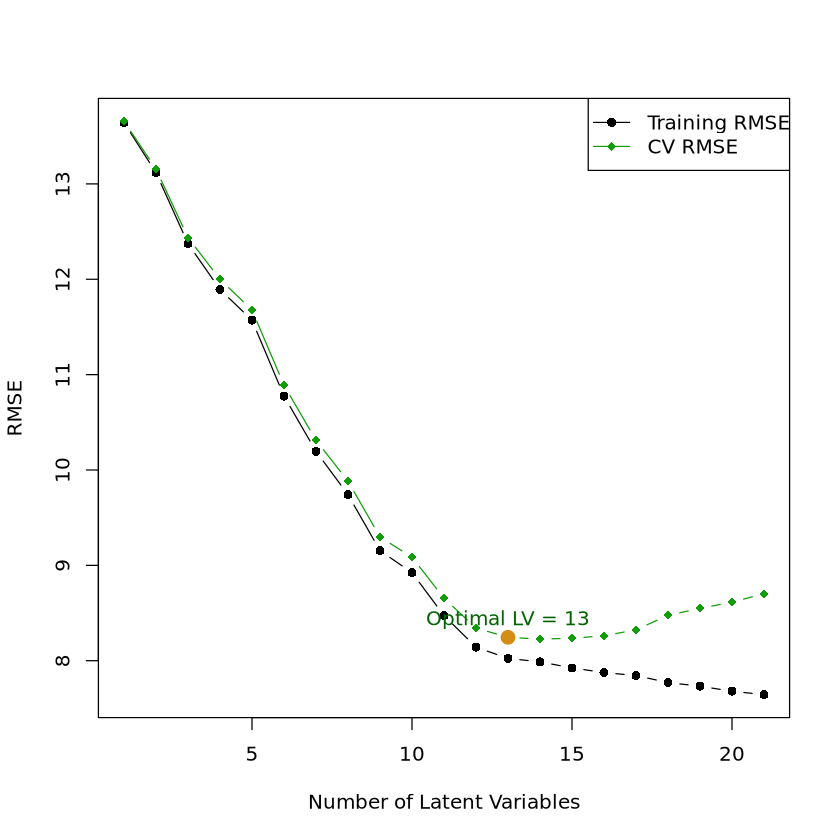

In [12]:
# apply PLSR
nXdat<-nXr00 

Ytrain <- as.matrix(lab$SOC[train])   # calibration set
Xtrain <- as.matrix(nXdat[train,])     # calibration set

# first we calculate the Model without cross validation, to see how well it ideally could perform (best R^2 possible)
modf <- plsr(Ytrain~Xtrain,       # variables
              ncomp=20,  # max. number of latent variables to compute
              method="oscorespls",    # oscorespls = NIPALS = standard PLS
              validation="none")      # without any validation
summary(modf)

# then we apply Model with 10-fold cross validation
set.seed(125)
modcv <- plsr(Ytrain~Xtrain,        # variables
              ncomp=20,   # max. number of latent variables to compute
              method="oscorespls",     # oscorespls = NIPALS 
              validation="CV",   # with n-fold cross-validation
              segments=10)       # n of segments = 10 --> 10-fold CV
summary(modcv)

# RMSE of model fit
err_fit<-RMSEP(modf)

# RMSE of cross validation
err_modcv<-RMSEP(modcv)

# amount of LVs
ncomp <- 1:length(err_fit$val[1,1,])

# RMSE Training
train_rmse <- err_fit$val[1,1,]

# RMSE CV
cv_rmse <- err_modcv$val[1,1,]

# optimal amount of CV
optimal_lv <- which.min(cv_rmse) -1
optimal_lv

# Plot Training RMSE
plot(ncomp, train_rmse, type="b", col="#000000", pch=16,
     xlab="Number of Latent Variables", ylab="RMSE",
     ylim=range(c(train_rmse, cv_rmse)))

# Plot CV RMSE
lines(ncomp, cv_rmse, type="b", col="#129d0b", pch=18)

legend("topright",
       legend=c("Training RMSE", "CV RMSE"),
       col=c("#000000","#129d0b"),
       pch=c(16,18),
       lty=1)

# add optimal LV in plot
points(optimal_lv, cv_rmse[optimal_lv], col="#d48e14", pch=19, cex=1.5)
text(optimal_lv, cv_rmse[optimal_lv], labels=paste("Optimal LV =", optimal_lv),
     pos=3, col="darkgreen")

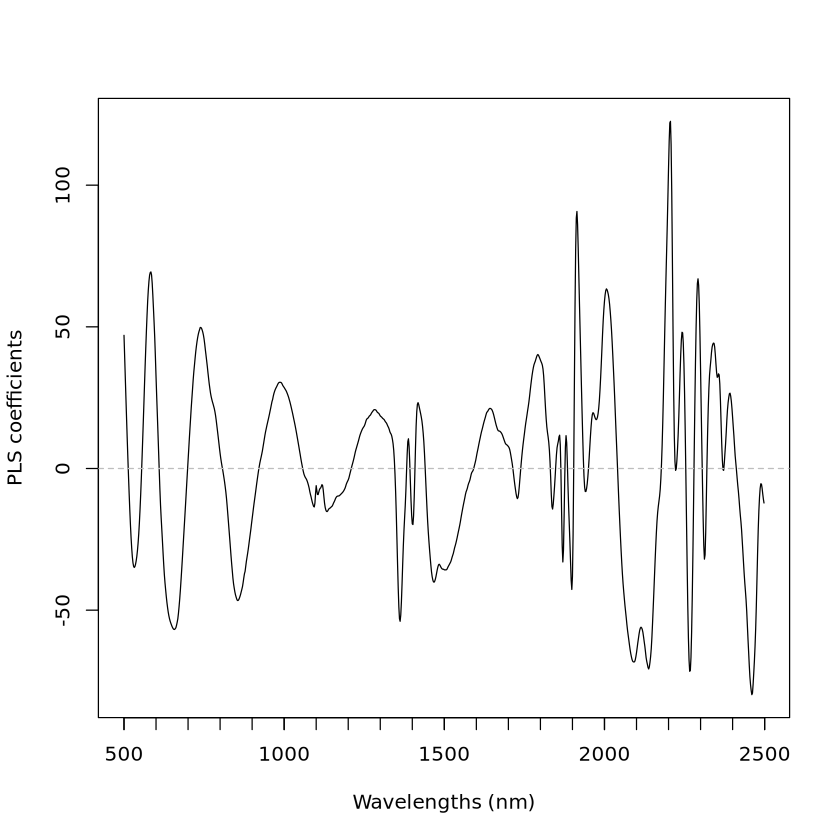

[1] 0.64 8.16 1.67


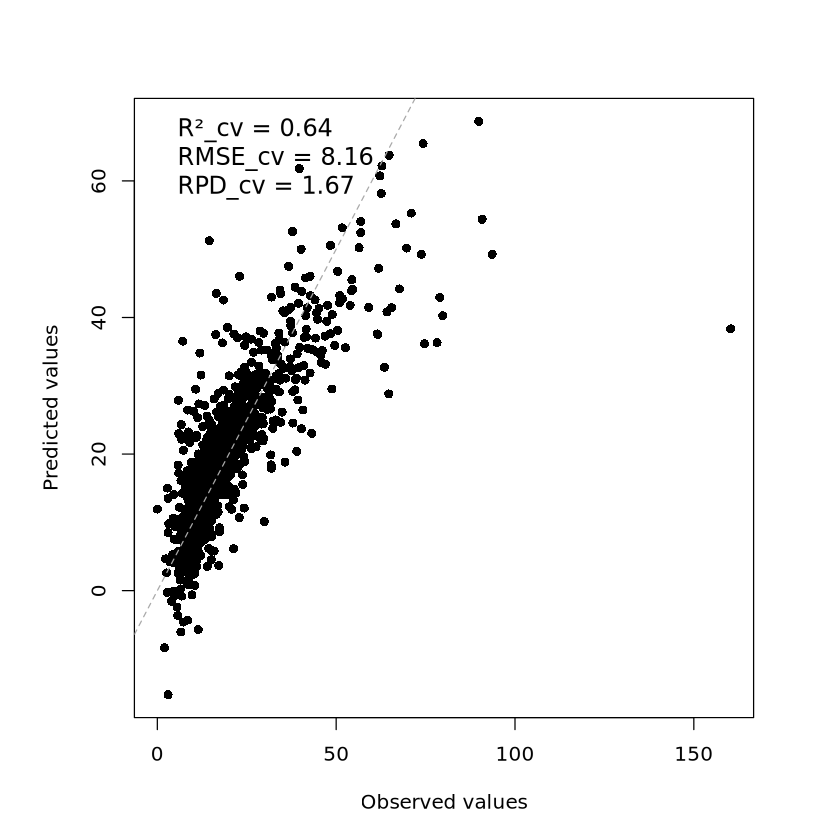

In [13]:
# Combine into one data frame
traindat <- data.frame(target = Ytrain, Xtrain)

# Cross-validation setup
set.seed(123)
control <- trainControl(method = "cv", number = 10, savePredictions = "final")

# Grid for tuning latent variables
tuneGrid <- expand.grid(ncomp = 1:20)

# Train PLSR
set.seed(123)
plsr_model <- train(target ~ .,
                    data = traindat,
                    method = "pls",
                    preProcess = c("center"),
                    trControl = control,
                    tuneGrid = tuneGrid)
                    
# set optimal amount of LVs
onc <- plsr_model$bestTune$ncomp

par(pty="m")
matplot(wl, coef(plsr_model$finalModel, ncomp = onc), type="l", lty=1,
        xlab="Wavelengths (nm)", ylab="PLS coefficients")
axis(1, seq(500,2500,100), labels = NA)
abline(h=0, lty=2, col="gray")

# CV predictions saved by caret
Ycv <- plsr_model$pred$pred[plsr_model$pred$ncomp == onc]
Yobs <- plsr_model$pred$obs[plsr_model$pred$ncomp == onc]

par(pty="s")
plot(Yobs, Ycv, pch=16, xlab="Observed values", ylab="Predicted values")
abline(0,1, lty=2, col="darkgrey")

np <- length(Yobs)

SST <- sum((Yobs - mean(Yobs))^2)
SSE <- sum((Ycv - Yobs)^2)
R2 <- round(1 - SSE/SST, 2)
RMSE <- round(sqrt(SSE/np), 2)
RPD <- round(sd(Yobs)/RMSE, 2)

print(c(R2, RMSE, RPD))

# legend
legend_text <- c(paste("R²_cv =", R2),
                 paste("RMSE_cv =", RMSE),
                 paste("RPD_cv =", RPD))
legend("topleft", legend=legend_text, bty="n", cex=1.2)


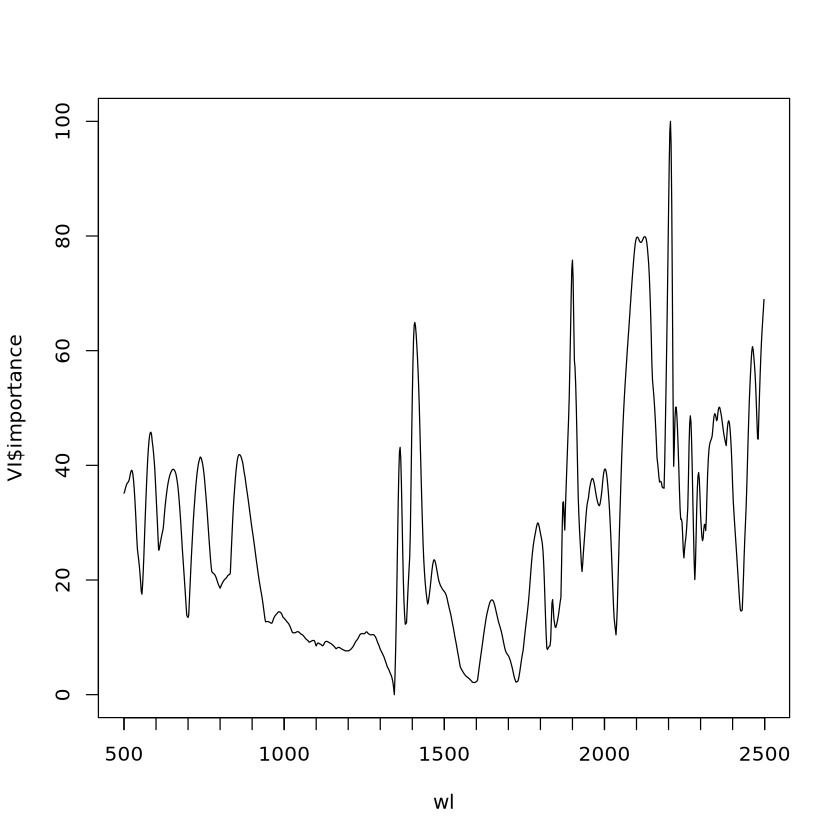

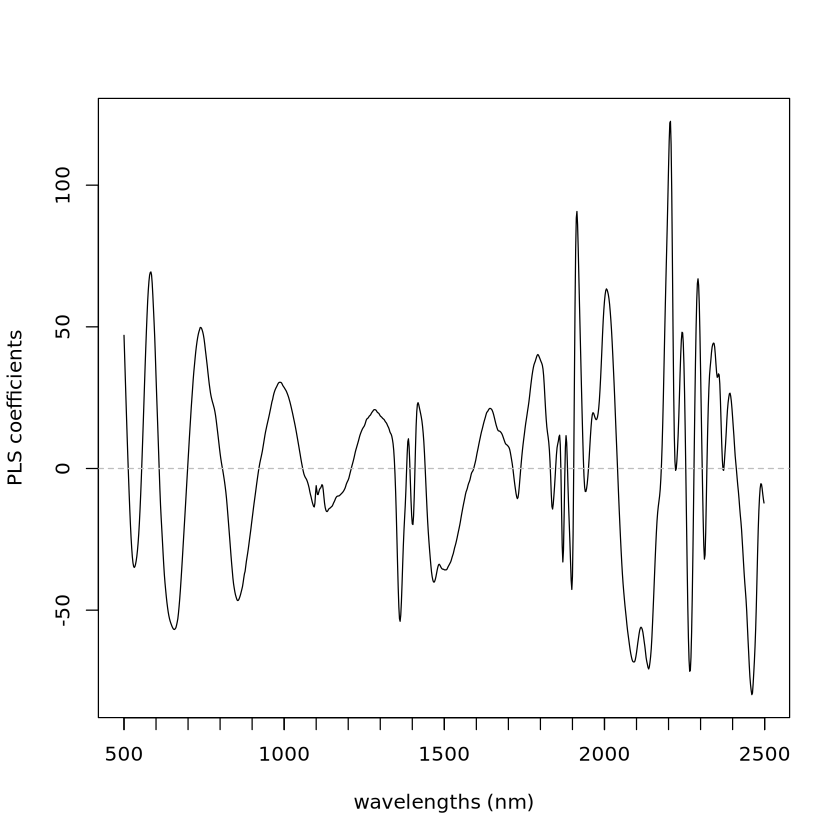

[1] 0.61

[1] 12.6

[1] 1.61

[1]  0.61 12.60  1.61


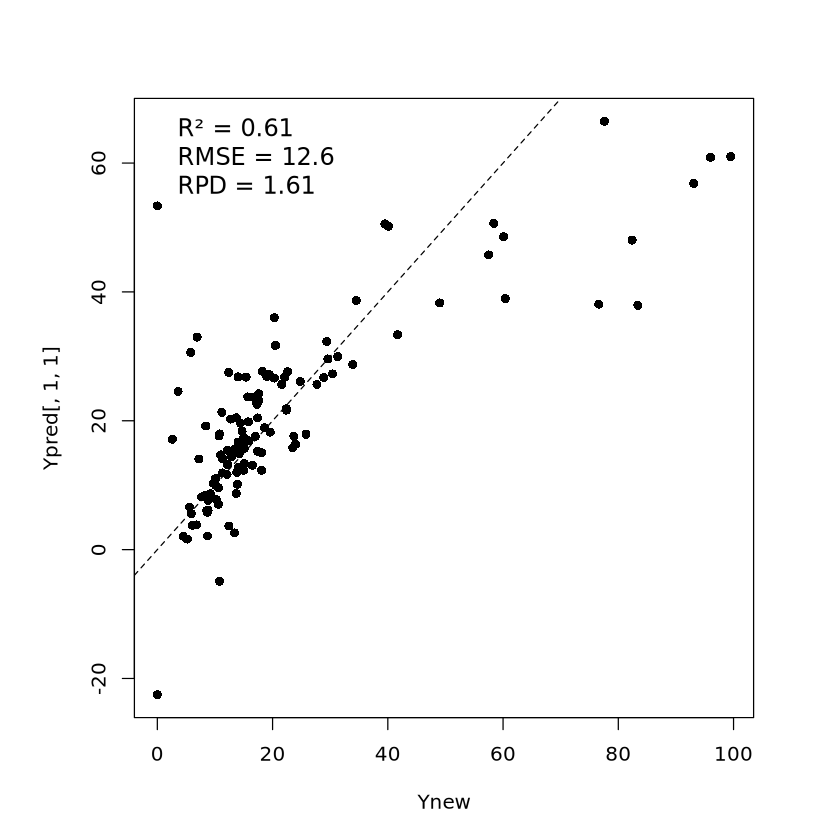

In [14]:
# Prediction on test set

Ynew <- as.matrix(lab$SOC[test])  # test set
Xnew <- as.matrix(nXdat[test,])    # test set

# actual prediction:
Ypred <- predict(object=modcv,    # prediction based on model
                 ncomp=onc,       # optimal number of latent variables
                 newdata = Xnew)  # new, 'unknown' data

VI<-varImp(plsr_model)
matplot(wl, VI$importance, type="l", lty=1)
axis(1, seq(500,2500,100), labels = NA)

# regression coefficients from train object:
par(pty="m")          # pty="m" --> maximizing plot to plot window
matplot(wl, coef(plsr_model$finalModel, ncomp=plsr_model$bestTune$ncomp), 
        type="l", lty=1,
        xlab="wavelengths (nm)", ylab="PLS coefficients")
axis(1, seq(500,2500,100), labels = NA)
abline(h=0, lty=2, col="gray")

# Scatter plot:
par(pty="s")
matplot(Ynew, 
        Ypred[,1,1], 
        pch=16)
abline(0,1, lty=2)   # 1:1 line

# validation metrics:
np<-nrow(Ynew)     # number of predictions

# calculation of R²:
SST<-sum((Ynew-mean(Ynew))^2)        
SSE<-sum((Ynew-Ypred[,1,1])^2)
R2<-round(1-(SSE/SST), digits=2)
R2

# calculation of RMSE
RMSE<-round(sqrt(sum((Ypred[,1,1]-Ynew)^2)/np), digits=2)
RMSE

# Calculation of RPD
RPD<-round(sd(Ynew)/RMSE, digits=2)
RPD

print(c(R2, RMSE, RPD))

# text for the legend
legend_text <- c(paste("R² =", R2),
                 paste("RMSE =", RMSE),
                 paste("RPD =", RPD))

# legend
legend("topleft", legend=legend_text, bty="n", cex=1.2)